In [52]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error

In [2]:
#Loading the data set
df=pd.read_csv(r"C:\Users\Shiva\Downloads\salary_data.csv")

In [3]:
df.columns

Index(['YearsExperience', 'Salary'], dtype='object')

In [5]:
df.head()

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0


In [6]:
#feature and target
X=df[['YearsExperience']]
Y=df['Salary']

In [7]:
#split
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=42)

In [8]:
#model training
model = LinearRegression()
model.fit(X_train,Y_train)

LinearRegression()

In [9]:
#prediction
Y_pred=model.predict(X_test)

In [10]:
#model evaluation
print("R2 score: ",r2_score(Y_test,Y_pred))
print("MAE: ", mean_absolute_error(Y_test,Y_pred))

R2 score:  0.9024461774180497
MAE:  6286.453830757749


In [11]:
# Check Learned Coefficients
print("Slope (m):", model.coef_[0])
print("Intercept (b):", model.intercept_)

Slope (m): 9423.815323030976
Intercept (b): 25321.583011776813


# “We trained a Linear Regression model on salary data. The model achieved 90% accuracy (R² = 0.90), with an average error of ₹6,200.The coefficient shows that each year of experience contributes an additional ₹9,424 to salary. Even freshers start with approximately ₹25,300.Therefore, the model is reliable and interpretable for salary forecasting.”

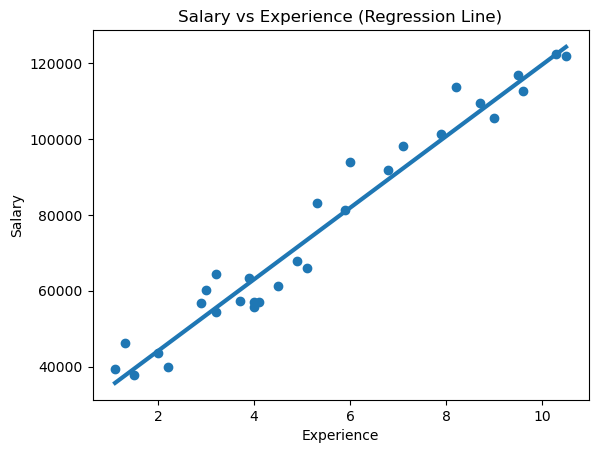

In [17]:
#visualize regression line
import matplotlib.pyplot as plt
plt.scatter(X,Y)
plt.plot(X,model.predict(X), linewidth=3)
plt.xlabel('Experience')
plt.ylabel('Salary')
plt.title("Salary vs Experience (Regression Line)")
plt.show()

In [19]:
#Predict Salary for New Experience Values
#new_emp=[[5],[8],[12]]
new_emp=pd.DataFrame([[5], [8], [12]], columns=['YearsExperience'])
prediction=model.predict(new_emp)
print(prediction)

[ 72440.65962693 100712.10559602 138407.36688815]


In [21]:
#Save the Model for Deployment
import joblib
joblib.dump(model, "salary_prediction_model.pkl")
print("Model saved!")


Model saved!


In [22]:
model = joblib.load("salary_prediction_model.pkl")


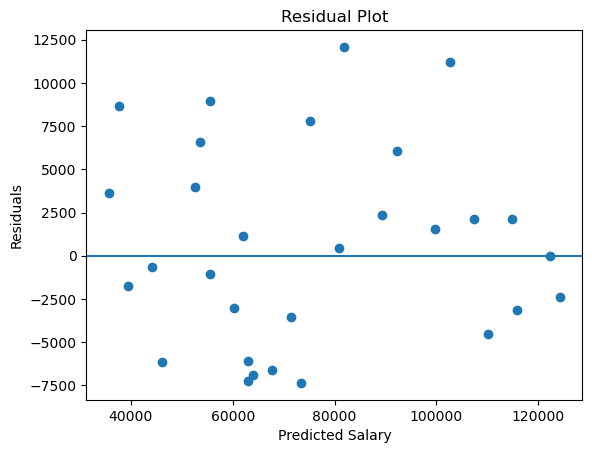

In [29]:
Y_pred = model.predict(X)
residuals = Y - Y_pred

plt.scatter(Y_pred, residuals)
plt.axhline(y=0)
plt.xlabel("Predicted Salary")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()


In [31]:
#Check for Overfitting
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

model.fit(X_train, Y_train)

train_score = r2_score(Y_train, model.predict(X_train))
test_score = r2_score(Y_test, model.predict(X_test))

print("Train R2 Score:", train_score)
print("Test R2 Score:", test_score)


Train R2 Score: 0.9645401573418146
Test R2 Score: 0.9024461774180497


In [45]:
df=pd.read_csv(r"C:\Users\Shiva\Downloads\salary_data.csv")

In [48]:
# Adding additional realistic features
import numpy as np
df['Age'] = df['YearsExperience'] + 22  # simple rule: graduate age approx. 22

# Education categories
df['Education'] = np.where(df['YearsExperience'] < 3, 'Bachelors',
                   np.where(df['YearsExperience'] < 6, 'Masters', 'PhD'))

df.head()


,YearsExperience,Salary,Age,Education
0,1.1,39343.0,23.1,Bachelors
1,1.3,46205.0,23.3,Bachelors
2,1.5,37731.0,23.5,Bachelors
3,2.0,43525.0,24.0,Bachelors
4,2.2,39891.0,24.2,Bachelors


In [49]:
#Encode Categorical Feature
df = pd.get_dummies(df, columns=['Education'], drop_first=True)
'''Machine Learning models can only work with numbers
But if your dataset contains categorical columns like:
Education = ["Bachelor", "Master", "PhD"]
We need to convert them into numeric columns → This process is called One-Hot Encoding.'''
df.head()


,YearsExperience,Salary,Age,Education_Masters,Education_PhD
0,1.1,39343.0,23.1,False,False
1,1.3,46205.0,23.3,False,False
2,1.5,37731.0,23.5,False,False
3,2.0,43525.0,24.0,False,False
4,2.2,39891.0,24.2,False,False


In [50]:
#Feature Selection (Now multiple)
X = df[['YearsExperience', 'Age', 'Education_Masters', 'Education_PhD']]
y = df['Salary']


In [53]:
#split
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=42)
#model visulazation
model= LinearRegression()
model.fit(X_train,Y_train)
#prediction
Y_pred=model.predict(X_test)
#model evaluation
print("R2 score: ", r2_score(Y_test,Y_pred))
print("MAE: ",mean_absolute_error(Y_test,Y_pred))
print("RMSE : ",np.sqrt(mean_squared_error(Y_test,Y_pred)))

R2 score:  0.8841117764220013
MAE:  6071.842812914001
RMSE :  7693.843936077733


In [54]:
#Coefficients (Feature Importance)
coeff_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})
coeff_df


,Feature,Coefficient
0,YearsExperience,3603.222784
1,Age,3603.222784
2,Education_Masters,929.539330
3,Education_PhD,15461.141982


In [56]:
#New Prediction Example
new_data = pd.DataFrame([[4, 26, 1, 0]], 
                        columns=['YearsExperience','Age','Education_Masters','Education_PhD'])
print("Predicted Salary:", model.predict(new_data)[0])


Predicted Salary: 60433.00472611026
